#  Pharma Demand Analysis — EDA

---

##  Context

This dataset combines:

- Real pharmaceutical demand patterns (monthly prescription data)
- Simulated supply chain features (pharmacies, cities, stock, lead time)

The goal is to analyze demand behavior and understand patterns that will inform forecasting and supply decisions.

---

##  Objectives

- Understand demand distribution across drugs
- Identify seasonality and trends
- Analyze variability and spikes in demand
- Examine supply-demand gaps (stock vs demand)
- Compare demand across cities and pharmacies




# 1.0 Libraries

In [1]:
# Data tool kit
import pandas as pd
import numpy as np

# Visualization tool
import  matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("imported sucessfully")

imported sucessfully


# 2.0 Data Loading

In [2]:
df = pd.read_parquet("../data/processed/final_pharmalink_dataset.parquet")
df.head()

,date,drug,demand,cost,pharmacy_id,city,stock,lead_time_days
0,2021-01-01,Amoxicillin,309442,558748.88,1,Tier2,309418,4
1,2021-01-01,Amoxicillin,513312,558748.88,2,Tier2,513397,4
2,2021-01-01,Amoxicillin,435921,558748.88,3,Tier2,435955,2
3,2021-01-01,Amoxicillin,388742,558748.88,4,Tier2,388704,3
4,2021-01-01,Amoxicillin,232121,558748.88,5,Tier3,232128,2


# 3.0 Summary Data


In [3]:
summary_rows = []

n_rows = len(df)

for column_name, column_data in df.items():

    missing_count = column_data.isna().sum()
    missing_ratio = (missing_count / n_rows) * 100

    example_values = column_data.dropna().unique()[:3]
    example_preview = ", ".join(map(str, example_values))[:60]

    summary_rows.append({
        "column_name": column_name,
        "dtype": column_data.dtype,
        "unique_values": column_data.nunique(),
        "missing_count": missing_count,
        "missing_percent": round(missing_ratio, 2),
        "example_values": example_preview
    })

dataset_summary = pd.DataFrame(summary_rows)

display(dataset_summary)

,column_name,dtype,unique_values,missing_count,missing_percent,example_values
0,date,datetime64[us],60,0,0.0,"2021-01-01 00:00:00, 2021-02-01 00:00:00, 2021..."
1,drug,str,3,0,0.0,"Amoxicillin, Paracetamol, Atorvastatin"
2,demand,int64,17961,0,0.0,"309442, 513312, 435921"
3,cost,float64,180,0,0.0,"558748.88, 449788.26, 525544.44"
4,pharmacy_id,int64,100,0,0.0,"1, 2, 3"
5,city,str,3,0,0.0,"Tier2, Tier3, Tier1"
6,stock,int64,17952,0,0.0,"309418, 513397, 435955"
7,lead_time_days,int32,6,0,0.0,"4, 2, 3"


# 4.0 Data Summary

In [4]:
# shape and size
display(df.shape)
display(df.size)

(18000, 8)

144000

In [5]:
# info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            18000 non-null  datetime64[us]
 1   drug            18000 non-null  str           
 2   demand          18000 non-null  int64         
 3   cost            18000 non-null  float64       
 4   pharmacy_id     18000 non-null  int64         
 5   city            18000 non-null  str           
 6   stock           18000 non-null  int64         
 7   lead_time_days  18000 non-null  int32         
dtypes: datetime64[us](1), float64(1), int32(1), int64(3), str(2)
memory usage: 1.3 MB


## 4.2 Duplication Analysis

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
# Summary Statistics
df.iloc[:, 1:].describe(include="all")

,drug,demand,cost,pharmacy_id,city,stock,lead_time_days
count,18000,1.800000e+04,1.800000e+04,18000.000000,18000,1.800000e+04,18000.000000
unique,3,NaN,NaN,NaN,3,NaN,NaN
top,Amoxicillin,NaN,NaN,NaN,Tier2,NaN,NaN
freq,6000,NaN,NaN,NaN,7241,NaN,NaN
mean,NaN,2.438235e+06,4.835792e+06,50.500000,NaN,2.438260e+06,3.497611
std,NaN,2.340788e+06,3.224207e+06,28.866872,NaN,2.340788e+06,1.709724
min,NaN,1.420550e+05,3.842582e+05,1.000000,NaN,1.420740e+05,1.000000
25%,NaN,7.224192e+05,1.413241e+06,25.750000,NaN,7.224468e+05,2.000000
50%,NaN,1.344526e+06,5.477288e+06,50.500000,NaN,1.344553e+06,4.000000
75%,NaN,3.906950e+06,6.183091e+06,75.250000,NaN,3.906978e+06,5.000000


# 4.3 Target Distribution

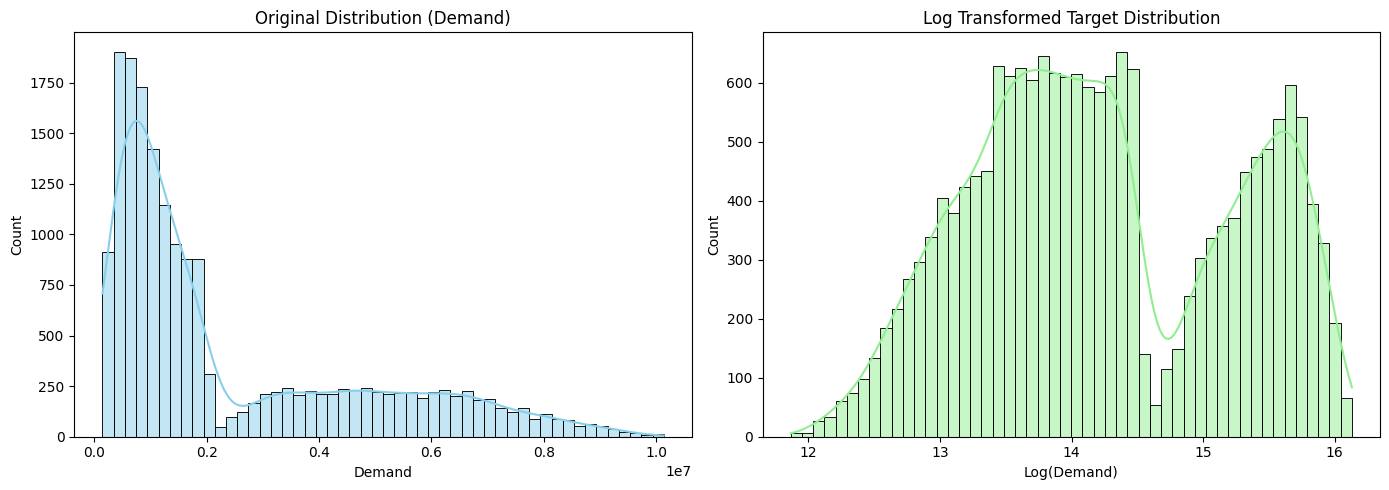

In [8]:
# Target Variable (Demand) Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Right skewed demand usually benefits from log transformation
sns.histplot(df['demand'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Original Distribution (Demand)')
axes[0].set_xlabel('Demand')

sns.histplot(np.log1p(df['demand']), bins=50, kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Log Transformed Target Distribution')
axes[1].set_xlabel('Log(Demand)')

plt.tight_layout()
plt.show()

# 4.4 Temporal Analysis (Time Series Patterns)
Aggregating demand by date allows us to see overarching trends over the months.

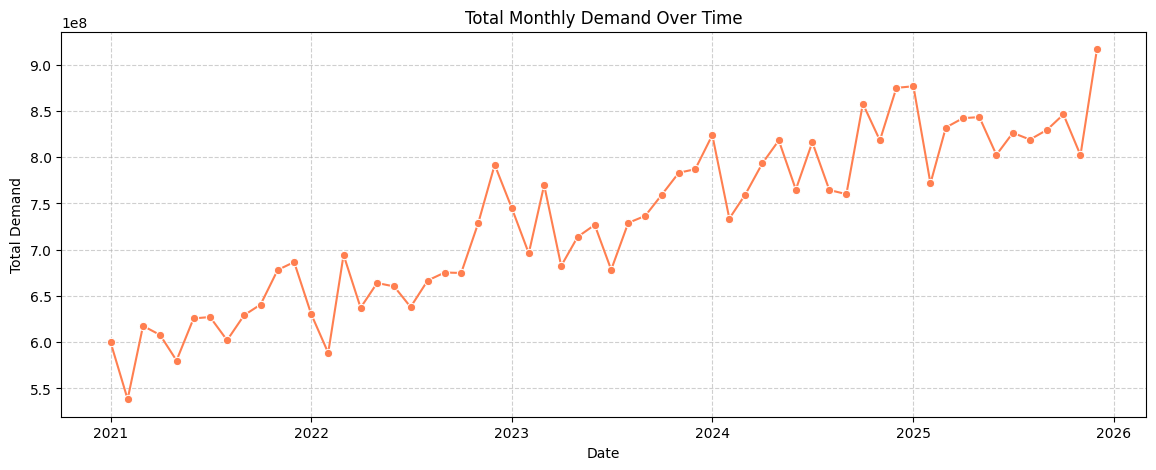

In [9]:
# Monthly Aggregated Demand
monthly_demand = df.groupby('date')['demand'].sum().reset_index()

plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly_demand, x='date', y='demand', marker='o', color='coral')
plt.title('Total Monthly Demand Over Time')
plt.xlabel('Date')
plt.ylabel('Total Demand')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 4.5 Segmented Analysis (Categorical Breaks)
How does demand fluctuate across drugs and cities?

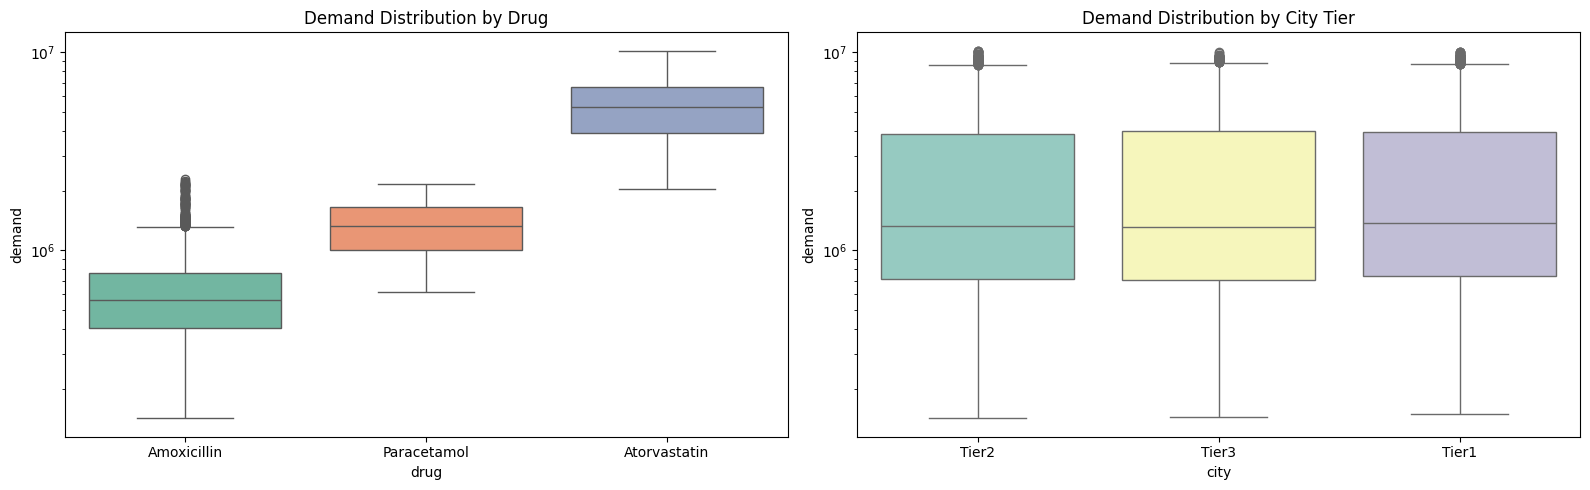

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Demand across Drugs
sns.boxplot(data=df, x='drug', y='demand', ax=axes[0], palette='Set2')
axes[0].set_title('Demand Distribution by Drug')
axes[0].set_yscale('log')  # Log scale for better visibility

# Demand across Cities
sns.boxplot(data=df, x='city', y='demand', ax=axes[1], palette='Set3')
axes[1].set_title('Demand Distribution by City Tier')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

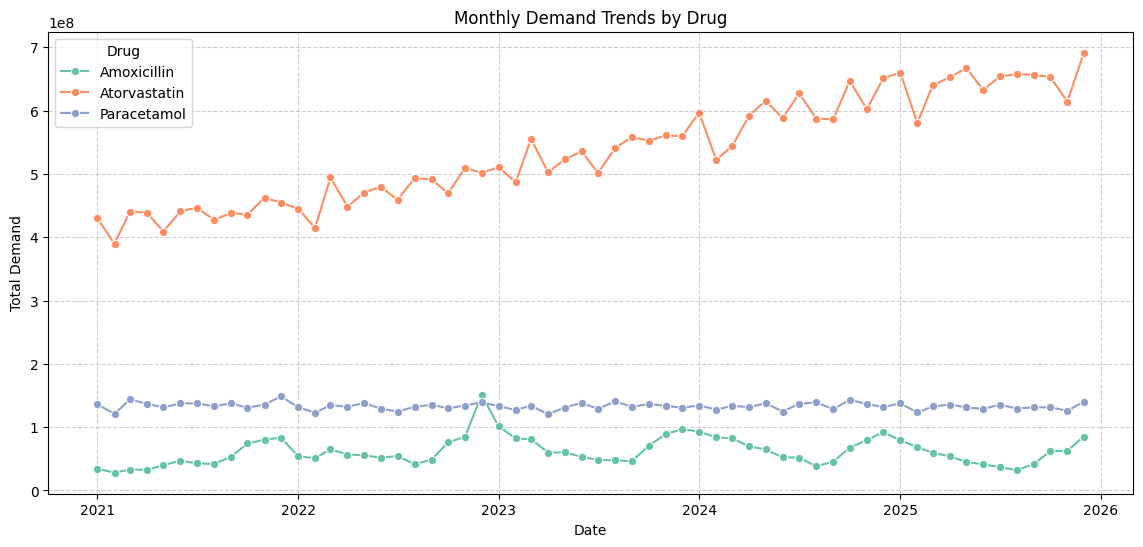

In [11]:
# Drug Demand Trends Over Time
drug_monthly = df.groupby(['date', 'drug'])['demand'].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=drug_monthly, x='date', y='demand', hue='drug', marker='o', palette='Set2')
plt.title('Monthly Demand Trends by Drug')
plt.xlabel('Date')
plt.ylabel('Total Demand')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Drug')
plt.show()

# 4.6 Supply vs. Demand Gap Analysis
A crucial part of our business problem is analyzing stockouts and overstock scenarios.

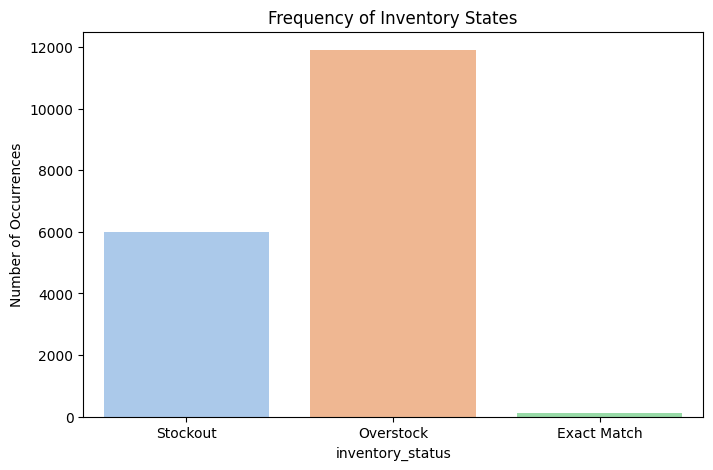

In [12]:
# Calculate Stock Gap
df['supply_gap'] = df['stock'] - df['demand']

def determine_status(gap):
    if gap < 0: return 'Stockout'
    if gap == 0: return 'Exact Match'
    return 'Overstock'

df['inventory_status'] = df['supply_gap'].apply(determine_status)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='inventory_status', palette='pastel')
plt.title('Frequency of Inventory States')
plt.ylabel('Number of Occurrences')
plt.show()

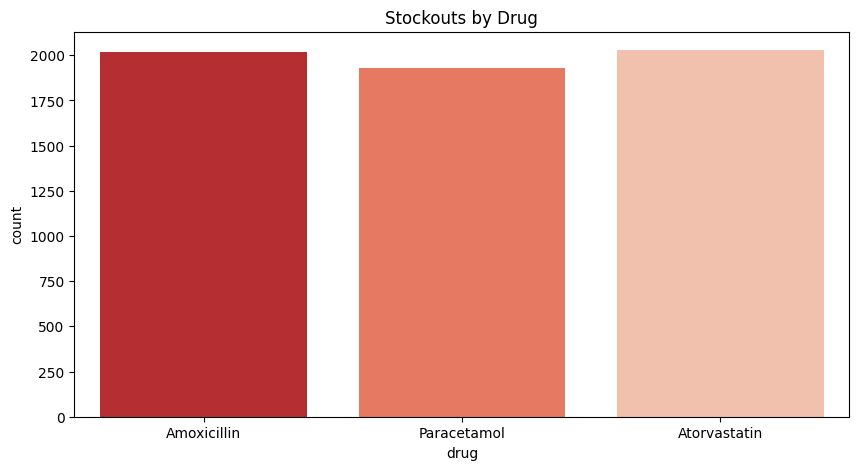

In [13]:
# Analyze severe stockouts (if any)
stockouts = df[df['inventory_status'] == 'Stockout']
if not stockouts.empty:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=stockouts, x='drug', palette='Reds_r')
    plt.title('Stockouts by Drug')
    plt.show()
else:
    print("Good news: No stockouts detected in this dataset.")

# 4.7 Feature Relationships
Plotting the correlation matrix for numerical features.

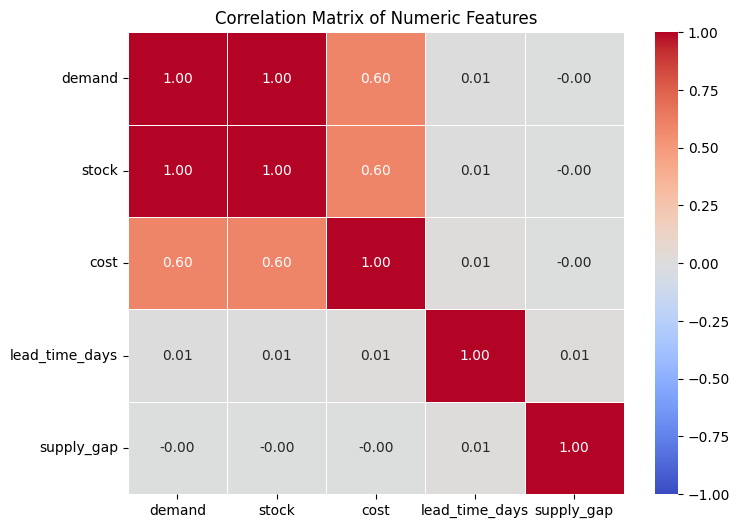

In [14]:
numeric_cols = ['demand', 'stock', 'cost', 'lead_time_days', 'supply_gap']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()